<H2>MERGING THE DATASETS</H2>
For our project, we will be merging two datasets, where:</br>
<li> Dataset1 contains census information such as literacy rate, urban population, rural population, unemployment, dominant religions, and 
</li>
<li> Dataset2 contains statistics of various crimes against women over the time span 2001-2020</li> </br>

In [2]:
import pandas as pd
import re
df = pd.read_csv('Final-censusdataset-India.csv')  
print(df.head(3))


    state                                       District  persons     Male  \
0  Andhra    District Adilabad (01), Andhra Pradesh (28)  2488003  1250958   
1  Andhra   District Nizamabad (02), Andhra Pradesh (28)  2345685  1162905   
2  Andhra  District Karimnagar (03), Andhra Pradesh (28)  3491822  1747968   

    Female    rural  Person lit_rate  Male lit_Rate  Female lit_Rate  \
0  1237045  1827986            52.68          64.98            40.30   
1  1182780  1920947            52.02          64.91            39.48   
2  1743854  2813010            54.90          67.09            42.75   

   Tempworkers  ...  religion1 population  Religion2  Religion2 Population  \
0      1423248  ...               2207843        NaN                236844   
1      1159606  ...               1983275  2.Muslims                338824   
2      1711559  ...               3251834  2.Muslims                213811   

      Religion3  religion3 Population inhabitadevillages  drinkingwater  \
0         

In [3]:
df.columns

Index(['state', 'District', 'persons', 'Male', 'Female', 'rural',
       'Person lit_rate', 'Male lit_Rate', 'Female lit_Rate', 'Tempworkers',
       'Mainworkers', 'Marginal workers', 'Nonworkers', 'Religion1',
       'religion1 population', 'Religion2', 'Religion2 Population',
       'Religion3', 'religion3 Population', 'inhabitadevillages',
       'drinkingwater', 'electricity', 'primary school', 'Medical facility'],
      dtype='object')

In [4]:
def clean_district_name(district_name):
    cleaned_name = district_name.replace("District ", "")
    cleaned_name = re.sub(r"\(\d+\), .* \(\d+\)", "", cleaned_name).strip()  
    return cleaned_name

df['District'] = df['District'].apply(clean_district_name)
df.to_csv('cleaned_district_name.csv', index=False)

In [5]:
df1 = pd.read_csv('cleaned_district_name.csv')  
print(df.head(3))

    state    District  persons     Male   Female    rural  Person lit_rate  \
0  Andhra    Adilabad  2488003  1250958  1237045  1827986            52.68   
1  Andhra   Nizamabad  2345685  1162905  1182780  1920947            52.02   
2  Andhra  Karimnagar  3491822  1747968  1743854  2813010            54.90   

   Male lit_Rate  Female lit_Rate  Tempworkers  ...  religion1 population  \
0          64.98            40.30      1423248  ...               2207843   
1          64.91            39.48      1159606  ...               1983275   
2          67.09            42.75      1711559  ...               3251834   

   Religion2  Religion2 Population     Religion3  religion3 Population  \
0        NaN                236844           NaN                 24392   
1  2.Muslims                338824  3.Christians                 16204   
2  2.Muslims                213811  3.Christians                 20576   

  inhabitadevillages  drinkingwater electricity  primary school  \
0             

In [6]:
df2 = pd.read_csv('women-crimedataset-India (2).csv')  
print(df2.head(3))


            state   District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0  ANDHRA PRADESH   ADILABAD  2001.0    101                60   50   
1  ANDHRA PRADESH  ANANTAPUR  2001.0    151               125   23   
2  ANDHRA PRADESH   CHITTOOR  2001.0    101                57   27   

  CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0              0         50                     46   
1              0         23                     53   
2              0         27                     59   

  KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  \
0                                          30   
1                                          30   
2                                          34   

  KIDNAPPING AND ABDUCTION OF OTHERS DOWRY DEATHS  \
0                                 16           16   
1                                 23            7   
2                                 25           14   

  ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY  \
0                                  

In [7]:
df2.columns

Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'],
      dtype='object')

In [8]:
df1['District'] = df1['District'].str.strip().str.lower()
df2['District'] = df2['District'].str.strip().str.lower()

In [9]:
state_replacements = {
    'andhra': 'ANDHRA PRADESH',
    'd & n haweli': 'D & N HAVELI',
    'delhi': 'DELHI UT',
    'hp': 'HIMACHAL PRADESH',
    'jk': 'JAMMU & KASHMIR',
    'tn': 'TAMIL NADU',
    'up': 'UTTAR PRADESH'
}

df1['state'] = df1['state'].replace(state_replacements)
df2['state'] = df2['state'].replace(state_replacements)

In [10]:
merged_df = pd.merge(df2, df1, left_on='District', right_on='District', how='inner')


In [11]:
merged_df.head()

,state_x,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion1 population,Religion2,Religion2 Population,Religion3,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility
0,ANDHRA PRADESH,adilabad,2001.0,101,60,50,0,50,46,30,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
1,ANDHRA PRADESH,anantapur,2001.0,151,125,23,0,23,53,30,...,3225156,2.Muslims,389201,3.Christians,20770,925.0,925.0,925.0,900.0,595
2,ANDHRA PRADESH,chittoor,2001.0,101,57,27,0,27,59,34,...,3368878,2.Muslims,342965,3.Christians,28337,1480.0,1479.0,1480.0,1365.0,683
3,ANDHRA PRADESH,cuddapah,2001.0,80,53,20,0,20,25,20,...,2181572,2.Muslims,386900,3.Christians,28978,876.0,875.0,875.0,853.0,432
4,ANDHRA PRADESH,guntur,2001.0,182,88,54,0,54,82,51,...,3834204,2.Muslims,487839,3.Christians,131713,694.0,694.0,694.0,690.0,584


In [12]:
merged_df.to_csv('merged_dataset.csv', index=False)


<H2>DATA PREPROCESSING:</H2>
<p>Since we have two columns containing State name values, we will drop one of the columns</p>

In [14]:
merged_df.rename(columns={'state_x': 'state'}, inplace=True)
merged_df.drop(columns=['state_y'], inplace=True)

print(merged_df.head(3))
merged_df.to_csv('merged_dataset.csv', index=False)

            state   District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0  ANDHRA PRADESH   adilabad  2001.0    101                60   50   
1  ANDHRA PRADESH  anantapur  2001.0    151               125   23   
2  ANDHRA PRADESH   chittoor  2001.0    101                57   27   

  CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0              0         50                     46   
1              0         23                     53   
2              0         27                     59   

  KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ... religion1 population  \
0                                          30  ...              2207843   
1                                          30  ...              3225156   
2                                          34  ...              3368878   

   Religion2 Religion2 Population     Religion3 religion3 Population  \
0        NaN               236844           NaN                24392   
1  2.Muslims               389201  3.Christians          

<H3> REARRANGING THE MERGED DATASET IN ASCENDING ORDER (IN ORDER OF 'state', 'District', 'YEAR' columns) and RESETTING THE INDEX</H3>


In [16]:
merged_df = merged_df.sort_values(by=['state', 'District', 'YEAR'])
merged_df = merged_df.reset_index(drop=True)
merged_df.describe

<bound method NDFrame.describe of                state        District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0     ANDHRA PRADESH        adilabad  2001.0    101                60   50   
1     ANDHRA PRADESH        adilabad  2002.0    100                79   37   
2     ANDHRA PRADESH        adilabad  2003.0    107                65   35   
3     ANDHRA PRADESH        adilabad  2004.0    113                83   50   
4     ANDHRA PRADESH        adilabad  2005.0    108                48   53   
...              ...             ...     ...    ...               ...  ...   
6479     WEST BENGAL  uttar dinajpur  2010.0     63               106  130   
6480     WEST BENGAL  uttar dinajpur  2011.0     66               178  126   
6481     WEST BENGAL  uttar dinajpur  2012.0    110               283   92   
6482     WEST BENGAL  uttar dinajpur  2015.0    NaN                86   50   
6483     WEST BENGAL  uttar dinajpur  2019.0      0                39   42   

     CUSTODIAL RAPE OTHER RAP

<H3> STANDARDIZING ALL THE STATE NAMES</H3>


In [18]:
def standardize_state_name(state_name):
    state_mapping = {
        'CHHATISGARH': 'CHHATTISGARH',
        'CHHATTISGARH': 'CHHATTISGARH',
        'CHATTISGARH': 'CHHATTISGARH',
        'TAMILNADU': 'TAMIL NADU',
        'TAMIL NADU': 'TAMIL NADU',
        'Chandigarh': 'CHANDIGARH',
        'CHANDIGARH': 'CHANDIGARH',
        'DELHI': 'DELHI UT',
        'DELHI UT': 'DELHI UT',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYAPRADESH': 'MADHYA PRADESH',
        'Lakshadweep': 'LAKSHADWEEP',
        'LAKSHADWEEP': 'LAKSHADWEEP',
        'ANDHRA PRADESH ': 'ANDHRA PRADESH',
        'ANDHRA PRADESH': 'ANDHRA PRADESH',
        
    }
    return state_mapping.get(state_name, state_name)

merged_df['state'] = merged_df['state'].apply(standardize_state_name)

merged_df['state'].unique()

array(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR',
       'CHANDIGARH', 'CHHATTISGARH', 'DELHI UT', 'GOA', 'GUJARAT',
       'HARYANA', 'HIMACHAL PRADESH', 'JHARKHAND', 'KARNATAKA', 'KERALA',
       'MADHYA PRADESH', 'MADHYA PRADESH  ', 'MAHARASHTRA', 'MANIPUR',
       'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUNJAB',
       'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA',
       'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL'], dtype=object)

In [19]:
merged_df['Religion1'] = merged_df['Religion1'].str.split('.').str[1].str.strip()
merged_df['Religion2'] = merged_df['Religion2'].str.split('.').str[1].str.strip()
merged_df['Religion3'] = merged_df['Religion3'].str.split('.').str[1].str.strip()

print(merged_df)
merged_df.to_csv('merged_dataset.csv', index=False)


               state        District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0     ANDHRA PRADESH        adilabad  2001.0    101                60   50   
1     ANDHRA PRADESH        adilabad  2002.0    100                79   37   
2     ANDHRA PRADESH        adilabad  2003.0    107                65   35   
3     ANDHRA PRADESH        adilabad  2004.0    113                83   50   
4     ANDHRA PRADESH        adilabad  2005.0    108                48   53   
...              ...             ...     ...    ...               ...  ...   
6479     WEST BENGAL  uttar dinajpur  2010.0     63               106  130   
6480     WEST BENGAL  uttar dinajpur  2011.0     66               178  126   
6481     WEST BENGAL  uttar dinajpur  2012.0    110               283   92   
6482     WEST BENGAL  uttar dinajpur  2015.0    NaN                86   50   
6483     WEST BENGAL  uttar dinajpur  2019.0      0                39   42   

     CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0     

In [20]:
print(merged_df.columns)


Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'persons', 'Male',
       'Female', 'rural', 'Person lit_rate', 'Male lit_Rate',
       'Female lit_Rate', 'Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'Religion1', 'religion1 population', 'Religion2',
       'Religion2 Population', 'Religion3', 'religion3 Population',
       'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school',
       'Medical facility'],
      dtype='object')


For the purpose of this study, while analysing crime patterns against women in India, we will look at the recent census parameters: such as literacy rate (overall, male literacy, female literacy
'Total Population'
'Male Population',
'Female Population', 
'rural', 
'urban', 
'Personlit_rate',
'Mlit_Rate', 
'Flit_Rate', 
'Totalworkers',
'Mainworkers', 
'Marginal workers', 
'Nonworkers', 
'Religion1',
'religion1 population', 'Religion2', 'Religion2 Population',



and other irrelevant columns for the purpose of this study ie 'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility', we will drop from the dataset
       

<H2> DERIVED COLUMNS:</H2>

In [23]:
# Calculating unemployment rate
merged_df['unemployment_rate'] = (merged_df['Nonworkers'] / (merged_df['Tempworkers'] + merged_df['Mainworkers'] + merged_df['Marginal workers'])) * 100

# Calculating urban population
merged_df['persons'] = pd.to_numeric(merged_df['persons'], errors='coerce')
merged_df['rural'] = pd.to_numeric(merged_df['rural'], errors='coerce')
merged_df['urban_population'] = merged_df['persons'] - merged_df['rural']





In [24]:
#converting string values to numeric

columns_to_convert = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
    'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

for column in columns_to_convert:
    merged_df[column] = pd.to_numeric(merged_df[column], errors='coerce')

In [25]:
#Creating column of total number of offences

all_crimes = ['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                  'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                  'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                  'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                  'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                  'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES']

merged_df['total'] = merged_df[all_crimes].sum(axis=1)


In [26]:
#Creating column of total number of cognizable offences
"""As per CRPC Schedule I, the following are considered Cognizable offences
'MURDER', 'ATTEMPT TO MURDER', 'RAPE', ' CUSTODIAL RAPE', 'OTHER RAPE','KIDNAPPING & ABDUCTION', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS','KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

cognizable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Cognizable Offences'] = merged_df[cognizable_offences].sum(axis=1)



In [27]:
#Creating column of total number of Non-Bailable offences
"""As per CRPC Schedule I, the following are considered Non-Bailable offences
'MURDER', 'ATTEMPT TO MURDER', RAPE',' CUSTODIAL RAPE', 'OTHER RAPE', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS', 
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 
'CRUELTY BY HUSBAND OR HIS RELATIVES','IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

non_bailable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS',
    'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Non-Bailable Offences'] = merged_df[non_bailable_offences].sum(axis=1)


<H2> RENAMING CERTAIN COLUMNS:</H2>

In [29]:
merged_df.rename(columns={'rural': 'rural_population'}, inplace=True)

merged_df.rename(columns={'Religion1': 'First Dominant Religion'}, inplace=True)

merged_df.rename(columns={'Religion2': 'Second Dominant Religion'}, inplace=True)

merged_df.rename(columns={'persons': 'Total Population'}, inplace=True)

merged_df.rename(columns={'Male': 'Male Population'}, inplace=True)

merged_df.rename(columns={'Female': 'Female Population'}, inplace=True)

merged_df.rename(columns={'Person lit_rate': 'Total Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Male lit_Rate': 'Male Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Female lit_Rate': 'Female Literacy Rate'}, inplace=True)



<H2> REMOVING ANY DUPLICATE ROWS</H2>
<H4> removing duplicates where the state, District, and YEAR values are the same</H4>

In [31]:
merged_df = merged_df.drop_duplicates(subset=['state', 'District', 'YEAR'], keep='last')

merged_df

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility,unemployment_rate,urban_population,total,Total Cognizable Offences,Total Non-Bailable Offences
0,ANDHRA PRADESH,adilabad,2001.0,101.0,60,50,0.0,50.0,46,30,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,727.0,727.0,647.0
1,ANDHRA PRADESH,adilabad,2002.0,100.0,79,37,0.0,37.0,42,32,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,834.0,834.0,729.0
2,ANDHRA PRADESH,adilabad,2003.0,107.0,65,35,0.0,35.0,46,16,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,763.0,763.0,678.0
3,ANDHRA PRADESH,adilabad,2004.0,113.0,83,50,0.0,50.0,48,42,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,908.0,908.0,789.0
4,ANDHRA PRADESH,adilabad,2005.0,108.0,48,53,0.0,53.0,65,46,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,914.0,914.0,772.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,WEST BENGAL,uttar dinajpur,2010.0,63.0,106,130,0.0,130.0,118,99,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1259.0,1259.0,1140.0
6480,WEST BENGAL,uttar dinajpur,2011.0,66.0,178,126,0.0,126.0,172,149,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1418.0,1418.0,1245.0
6481,WEST BENGAL,uttar dinajpur,2012.0,110.0,283,92,0.0,92.0,306,258,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1976.0,1976.0,1665.0
6482,WEST BENGAL,uttar dinajpur,2015.0,NaN,86,50,0.0,NaN,1,72,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,844.0,844.0,838.0


<h2>DROPPING IRRELEVANT COLUMNS:</h2>

In [33]:
irrelevant_columns = ['inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility']
merged_df = merged_df.drop(columns=irrelevant_columns)

irrelevant_columns = ['Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'religion1 population', 
       'Religion2 Population', 'Religion3', 'religion3 Population']
merged_df = merged_df.drop(columns=irrelevant_columns)

print(merged_df.head(3))

            state  District    YEAR  MURDER  ATTEMPT TO MURDER  RAPE  \
0  ANDHRA PRADESH  adilabad  2001.0   101.0                 60    50   
1  ANDHRA PRADESH  adilabad  2002.0   100.0                 79    37   
2  ANDHRA PRADESH  adilabad  2003.0   107.0                 65    35   

   CUSTODIAL RAPE  OTHER RAPE  KIDNAPPING & ABDUCTION  \
0             0.0        50.0                      46   
1             0.0        37.0                      42   
2             0.0        35.0                      46   

   KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ...  Total Literacy Rate  \
0                                           30  ...                52.68   
1                                           32  ...                52.68   
2                                           16  ...                52.68   

   Male Literacy Rate  Female Literacy Rate  First Dominant Religion  \
0               64.98                  40.3                      NaN   
1               64.98            

In [34]:
merged_df.to_csv("all_done_1.csv",index=False)

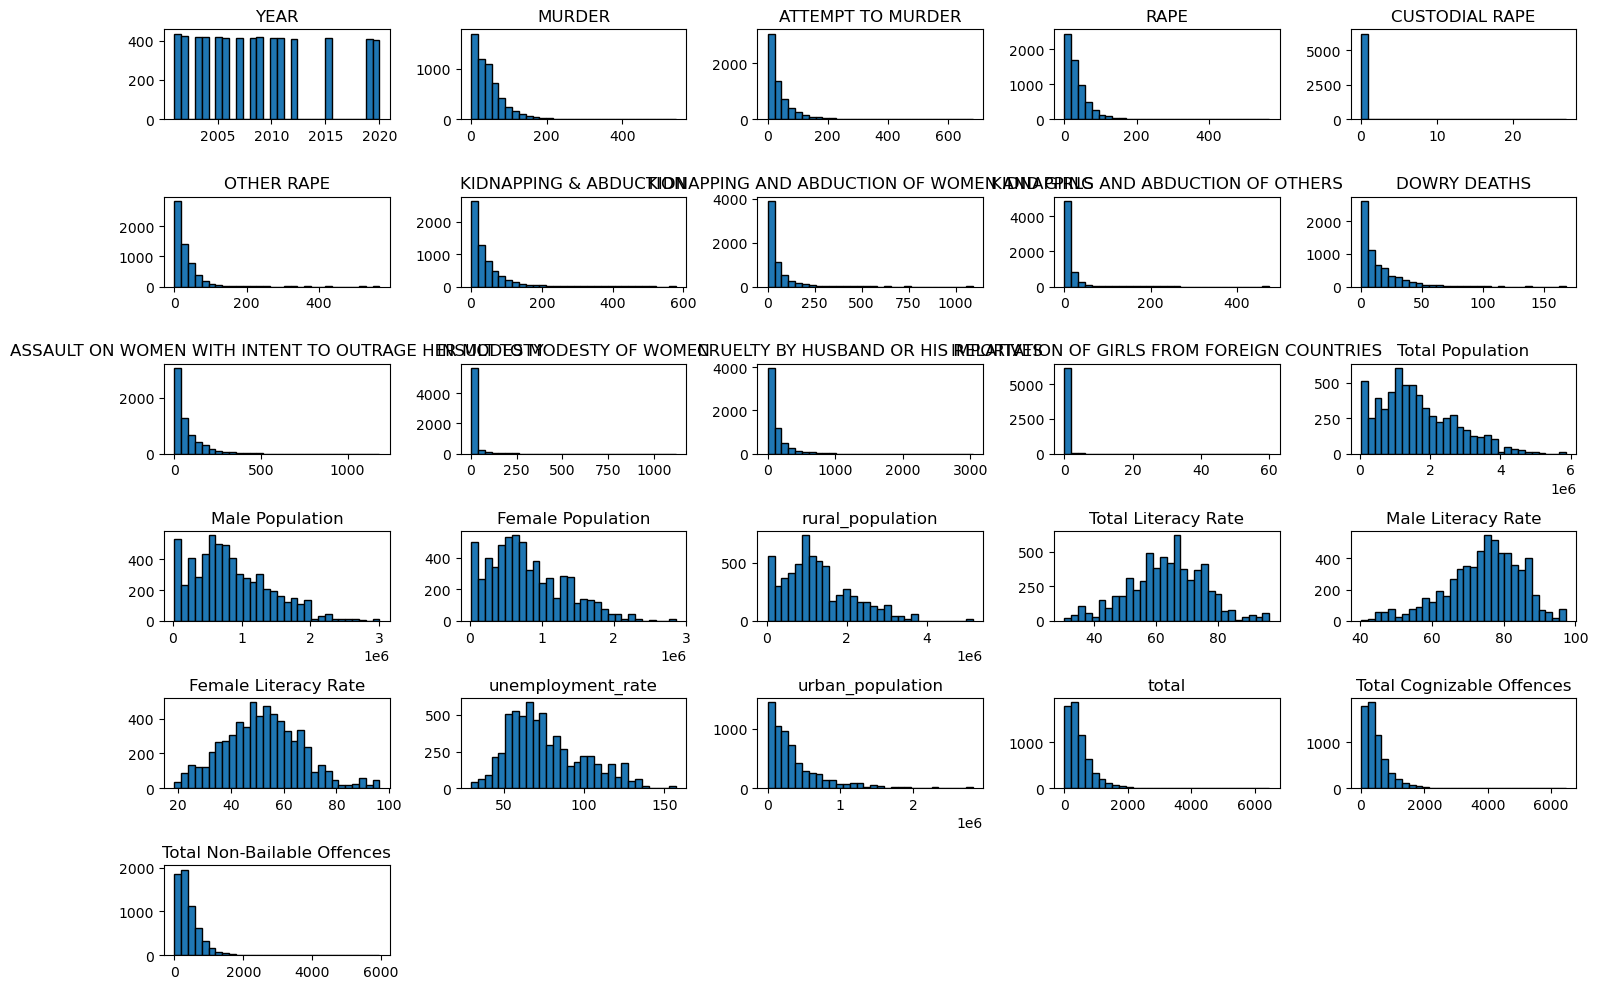

In [71]:
import matplotlib.pyplot as plt

# Create histograms for all numerical columns in merged_df
merged_df.hist(bins=30, figsize=(15, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()


<h2>FEATURE SELECTION</h2>

In [36]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = merged_df.drop(columns=["state", "District", "YEAR", "First Dominant Religion", "Second Dominant Religion"])  
y = merged_df["total"]

column_names = X.columns

imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

lasso_model = Lasso(alpha=0.04)  

lasso_model.fit(X_scaled, y)

selected_features_embedded = X.columns[lasso_model.coef_ != 0]

print("Embedded Method (Lasso Regression) Selected Features:", selected_features_embedded)


Embedded Method (Lasso Regression) Selected Features: Index(['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
       'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
       'Male Literacy Rate', 'urban_population', 'total',
       'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


In [37]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = merged_df.drop(columns=["state", "District", "YEAR", "First Dominant Religion", "Second Dominant Religion"])  
y = merged_df["total"]

column_names = X.columns

imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply feature selection
k_best = 5  # Choose the number of top features to select
selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
selector.fit(X_scaled, y)

# Get selected features
selected_features_filter = column_names[selector.get_support()]

print("Filter Method (SelectKBest) Selected Features:", selected_features_filter)


Filter Method (SelectKBest) Selected Features: Index(['CUSTODIAL RAPE', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'total', 'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


In [67]:
#FORWARD SELECTION
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

df5 = pd.read_csv('all_done_2_filled.csv')

df_encoded = pd.get_dummies(df5, columns=['state', 'District'])

X = df_encoded.drop(columns=['total'])  
y = df_encoded['total']  

lr = LinearRegression()

rfe_forward = RFE(estimator=lr, n_features_to_select=4, step=1)

rfe_forward.fit(X, y)

selected_features_forward = X.columns[rfe_forward.support_]

print("Selected Features (Forward Selection):", selected_features_forward)


Selected Features (Backward Elimination): Index(['KIDNAPPING & ABDUCTION', 'INSULT TO MODESTY OF WOMEN',
       'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


In [68]:
#BACKWARD ELIMINATION

rfe_backward = RFE(estimator=lr, n_features_to_select=4, step=1)  

rfe_backward.fit(X, y)

selected_features_backward = X.columns[rfe_backward.support_]

print("Selected Features (Backward Elimination):", selected_features_backward)


Selected Features (Backward Elimination): Index(['KIDNAPPING & ABDUCTION', 'INSULT TO MODESTY OF WOMEN',
       'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


<h2>HEATMAP</h2>

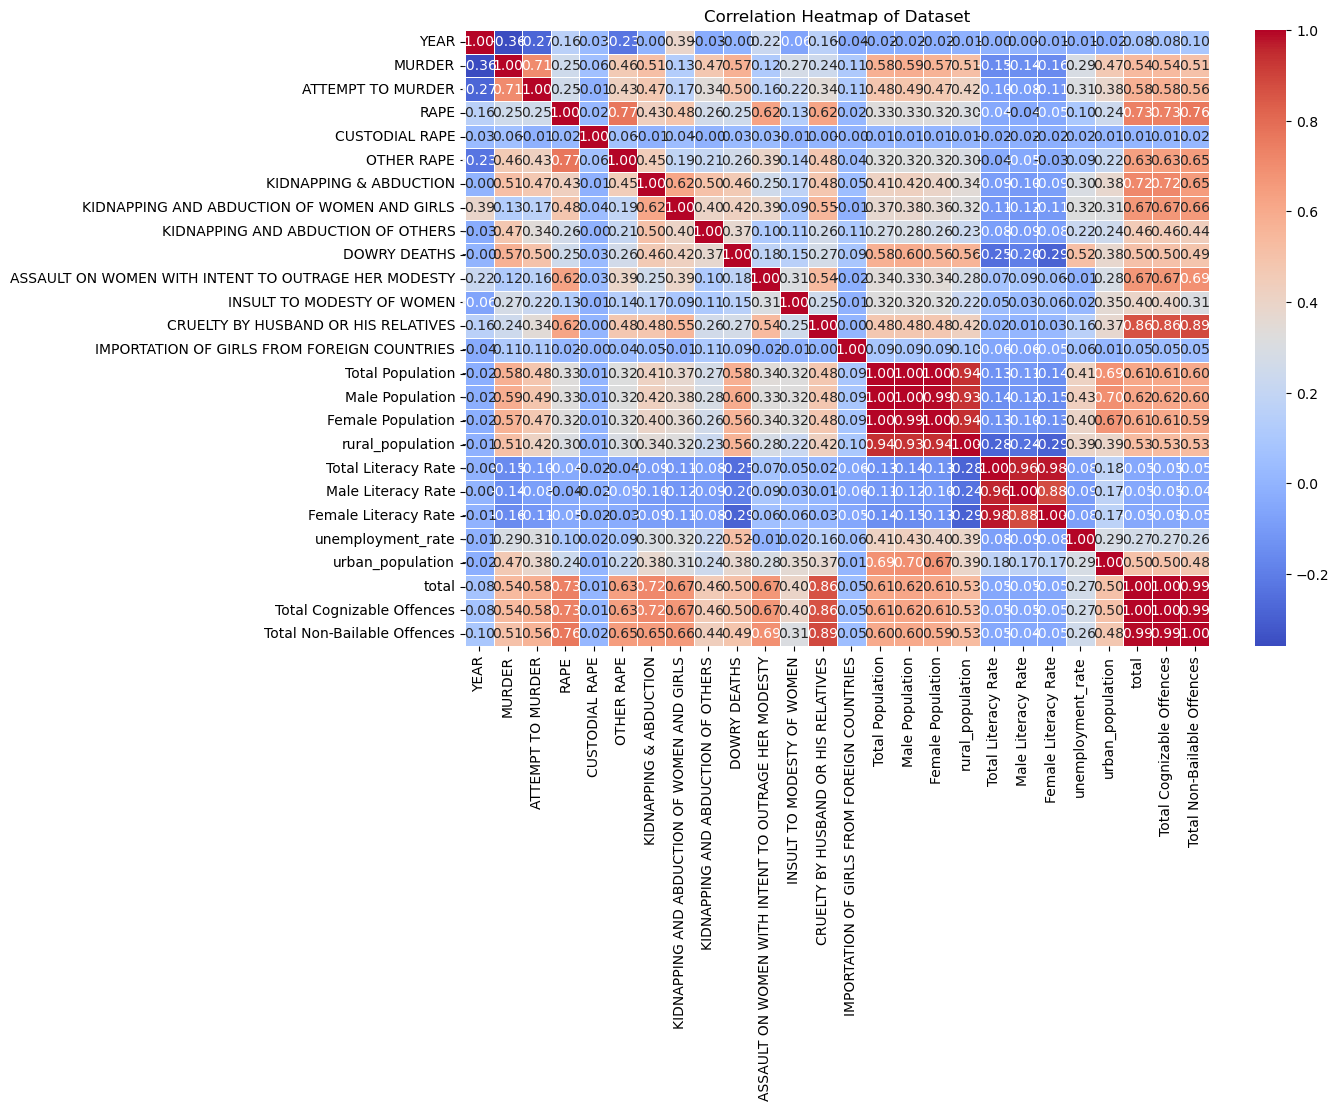

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = merged_df.select_dtypes(include=['number'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Dataset')
plt.show()


In [64]:
import pandas as pd
import numpy as np

numeric_df = merged_df.select_dtypes(include=['number'])

numeric_df = numeric_df.fillna(numeric_df.mean())

correlation_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
correlation_matrix = correlation_matrix.mask(mask)

top_correlated_pairs = []
top_correlated_triples = []
for col in correlation_matrix.columns:
    top_correlated_col = correlation_matrix[col].idxmax()
    max_corr = correlation_matrix[col].max()
    top_correlated_pairs.append((col, top_correlated_col, max_corr))
    
    for other_col in correlation_matrix.columns:
        if other_col != col and other_col != top_correlated_col:
            try:
                corr1 = correlation_matrix[col][other_col]
                corr2 = correlation_matrix[top_correlated_col][other_col]
                if np.isnan(corr1) or np.isnan(corr2):  
                    continue
                avg_corr = (corr1 + corr2) / 2
                top_correlated_triples.append((col, top_correlated_col, other_col, avg_corr))
            except KeyError:
                continue

top_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
top_correlated_triples.sort(key=lambda x: abs(x[3]), reverse=True)

top_5_correlated_pairs = top_correlated_pairs[:5]
top_5_correlated_triples = top_correlated_triples[:5]

print("Top 5 correlated column pairs:")
for pair in top_5_correlated_pairs:
    print(pair)

print("\nTop 5 correlated column triples:")
for triple in top_5_correlated_triples:
    print(triple)


Top 5 correlated column pairs:
('total', 'Total Cognizable Offences', 1.0)
('Total Population', 'Male Population', 0.9986128830799519)
('Male Population', 'Female Population', 0.994064733981623)
('Total Cognizable Offences', 'Total Non-Bailable Offences', 0.9899221675673969)
('Total Literacy Rate', 'Female Literacy Rate', 0.9765442703320122)

Top 5 correlated column triples:
('Total Population', 'Male Population', 'Female Population', 0.9962393420121396)
('total', 'Total Cognizable Offences', 'Total Non-Bailable Offences', 0.9899221675673969)
('Male Population', 'Female Population', 'rural_population', 0.9178086382676932)
('Total Population', 'Male Population', 'rural_population', 0.9148807848258171)
('KIDNAPPING & ABDUCTION', 'total', 'Total Cognizable Offences', 0.8592249564454444)


/var/folders/xn/1_g50z0x7z1cl56zcnwgl2sh0000gn/T/ipykernel_43089/3742298863.py:16: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  top_correlated_col = correlation_matrix[col].idxmax()


### Dataset after feature selection

In [66]:
import pandas as pd

df1 = pd.read_csv('all_done_1.csv')

desired_columns = ["state", "District", "YEAR",'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                   'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                   'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                   'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                   'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                   'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
                   'Male Literacy Rate', 'urban_population', 'total',
                   'Total Cognizable Offences', 'Total Non-Bailable Offences']

df1 = df1[desired_columns]

df1.to_csv('all_done_2.csv', index=False)


In [67]:
import pandas as pd

df4 = pd.read_csv('all_done_2.csv')

df_filled = df4.fillna(method='ffill').fillna(method='bfill')

df_filled.to_csv('all_done_2_filled.csv', index=False)


/var/folders/xn/1_g50z0x7z1cl56zcnwgl2sh0000gn/T/ipykernel_43089/2687710913.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df4.fillna(method='ffill').fillna(method='bfill')


<h2>DIMENSIONALITY REDUCTION</h2>

<OL>

<LI> PRINCIPAL COMPONENT ANALYSIS</LI></OL>


In [69]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = df5[['YEAR','MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
         'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
         'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
         'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
         'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
         'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
         'Male Literacy Rate', 'urban_population', 'total',
         'Total Cognizable Offences', 'Total Non-Bailable Offences']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=20)  
X_pca = pca.fit_transform(X_scaled)
# X_pca now contains the transformed features after PCA

explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)



Explained Variance Ratio: [4.10221436e-01 1.08529890e-01 7.16442865e-02 6.57491780e-02
 5.04853970e-02 4.85391060e-02 4.67577745e-02 3.96188260e-02
 2.82877282e-02 2.69941342e-02 2.35126253e-02 2.10072921e-02
 1.84909499e-02 1.25392192e-02 1.08357556e-02 1.02978179e-02
 6.26245774e-03 2.26126015e-04 4.19217179e-33 6.90639557e-35]


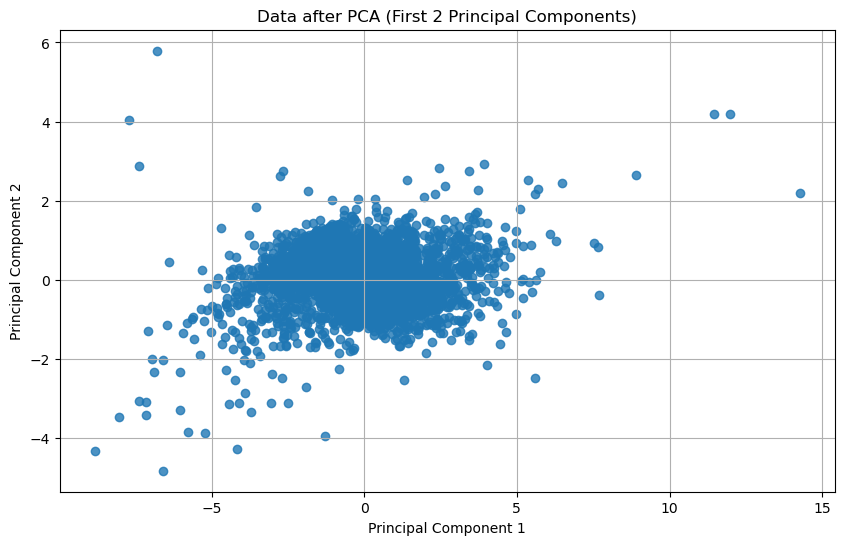

In [70]:
import matplotlib.pyplot as plt

# Plotting the data after PCA
def plot_pca_data(X_pca):
    plt.figure(figsize=(10, 6))
    plt.scatter(X_pca[:, 1], X_pca[:, 11], alpha=0.8)
    plt.title('Data after PCA (First 2 Principal Components)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

# Plot data after PCA
plot_pca_data(X_pca)


# PLOTS

In [73]:
final_df=pd.read_csv('all_done_2_filled.csv')

final_df.fillna(0, inplace=True)
#final_df.fillna(final_df.mean(), inplace=True)
final_df.to_csv('final_dataset.csv', index=False)


# Boxplots

In [75]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_boxplot(state, district, year_range, column):
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].isin(year_range))]
    
    plt.figure(figsize=(10, 6))
    filtered_df.boxplot(column=column)
    plt.title(f'Boxplot for {column} in {state}, {district} - Year {min(year_range)} to {max(year_range)}')
    plt.ylabel(column)
    plt.xticks(rotation=45)
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')
column_dropdown = widgets.Dropdown(options=['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                                            'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                                            'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                                            'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                                            'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                                            'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
                                            'Male Literacy Rate', 'urban_population', 'total',
                                            'Total Cognizable Offences', 'Total Non-Bailable Offences'], 
                                   description='Column:')

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_boxplot, state=state_dropdown, district=district_dropdown, year_range=year_range_slider, column=column_dropdown)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_boxplot(state, district, year_range, column)>

<h2>DENDOGRAM</h2>

In [86]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample DataFrame
# final_df should already be defined in your context
# final_df = pd.read_csv("your_data.csv")  # Load your dataset

def plot_dendrogram(state, district, year_range):
    # Filter the DataFrame
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].isin(year_range))]

    # Check if the filtered DataFrame is empty
    if filtered_df.empty:
        print("No data available for the selected state, district, and year range.")
        return

    # Select the relevant columns for clustering
    # Adjust this to include the columns you want to analyze
    data_to_cluster = filtered_df[['MURDER', 'RAPE', 'KIDNAPPING & ABDUCTION', 'DOWRY DEATHS']]

    # Handle missing values (optional)
    data_to_cluster = data_to_cluster.dropna()

    # Check if there's enough data for clustering
    if data_to_cluster.shape[0] < 2:
        print("Not enough data points for clustering.")
        return

    # Perform hierarchical clustering
    linked = linkage(data_to_cluster, method='ward')

    plt.figure(figsize=(12, 8))
    dendrogram(linked, 
               orientation='top', 
               labels=filtered_df['District'].values,
               distance_sort='descending',
               show_leaf_counts=True)
    
    plt.title(f'Dendrogram for {state}, {district} - Year {min(year_range)} to {max(year_range)}')
    plt.xlabel('District')
    plt.ylabel('Distance')
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

# Link the state dropdown to update districts
widgets.interactive(update_district_dropdown, state=state_dropdown)

# Create interactive plot
interact(plot_dendrogram, state=state_dropdown, district=district_dropdown, year_range=year_range_slider)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_dendrogram(state, district, year_range)>

# PIE CHART

In [77]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_crime_pie_chart(state, district, year_range):
    try:
        filtered_df = final_df[(final_df['state'] == state) & 
                               (final_df['District'] == district) & 
                               (final_df['YEAR'].between(year_range[0], year_range[1]))]

        total_crimes = filtered_df[['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                                     'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                                     'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                                     'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                                     'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                                     'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES']].sum()

        plt.figure(figsize=(8, 8))
        plt.pie(total_crimes, labels=total_crimes.index, autopct='%1.1f%%', startangle=140)
        plt.title(f'Crime Distribution in {state}, {district} - Year Range: {year_range[0]}-{year_range[1]}')
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
    except Exception as e:
        print("An error occurred:", e)

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')
district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_pie_chart, state=state_dropdown, district=district_dropdown, year_range=year_range_slider)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_crime_pie_chart(state, district, year_range)>

# HISTOGRAM

In [79]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_crime_histogram(state, district, year_range):
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].between(year_range[0], year_range[1]))]
    
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_df['Total Cognizable Offences'], bins=20, color='skyblue', edgecolor='black', alpha=0.5, label='Cognizable Offences')
    plt.hist(filtered_df['Total Non-Bailable Offences'], bins=20, color='salmon', edgecolor='black', alpha=0.5, label='Non-Bailable Offences')
    plt.title(f'Distribution of Cognizable Offences vs Non-Bailable Offences in {state}, {district} - Year Range: {year_range[0]}-{year_range[1]}')
    plt.xlabel('Number of Offences')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')
district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_histogram, state=state_dropdown, district=district_dropdown, year_range=year_range_slider)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_crime_histogram(state, district, year_range)>

In [81]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_crime_histogram(state, district, year_range):
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].between(year_range[0], year_range[1]))]
    
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_df['Total Cognizable Offences'], bins=20, color='skyblue', edgecolor='black', alpha=0.5, label='Cognizable Offences')
    plt.hist(filtered_df['Total Non-Bailable Offences'], bins=20, color='salmon', edgecolor='black', alpha=0.5, label='Non-Bailable Offences')
    plt.title(f'Distribution of Cognizable Offences vs Non-Bailable Offences in {state}, {district} - Year Range: {year_range[0]}-{year_range[1]}')
    plt.xlabel('Number of Offences')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')
district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_histogram, state=state_dropdown, district=district_dropdown, year_range=year_range_slider)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_crime_histogram(state, district, year_range)>

# LINE PLOT

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact, Layout

df6 = final_df

state_dropdown = widgets.Dropdown(options=df6['state'].unique(), description='State:', layout=Layout(width='300px'))
district_dropdown = widgets.Dropdown(description='District:', layout=Layout(width='300px'))

def update_district_dropdown(change):
    selected_state = change.new
    district_dropdown.options = df6[df6['state'] == selected_state]['District'].unique()

state_dropdown.observe(update_district_dropdown, names='value')

def plot_crime_trend(state, district):
    filtered_data = df6.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    plt.figure(figsize=(15, 8))
    for column in filtered_data.columns[3:-6]:  # Exclude non-relevant columns like 'state', 'District', 'YEAR', and totals
        x = filtered_data['YEAR'].values  # Convert to numpy array
        y = filtered_data[column].values  # Convert to numpy array
        plt.plot(x, y, label=column)
    plt.title('Crime Trend Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()

interact(plot_crime_trend, state=state_dropdown, district=district_dropdown)


interactive(children=(Dropdown(description='State:', layout=Layout(width='300px'), options=('ANDHRA PRADESH', …

<function __main__.plot_crime_trend(state, district)>

# SCATTER PLOT

<h3>Checking correlation between total number of crimes vs Male Literacy Rate</h3>

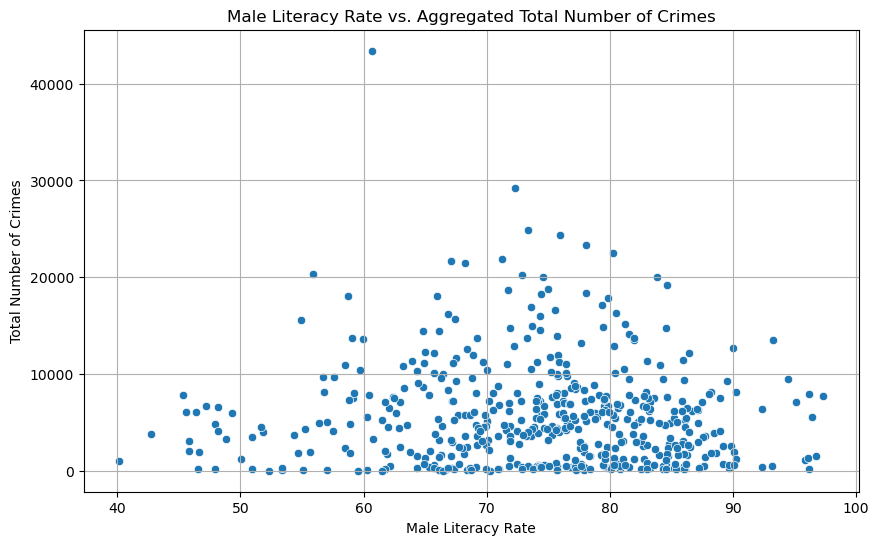

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_male_literacy_vs_aggregated_crimes(state=None, district=None):
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    aggregated_crimes = filtered_data.groupby(['state', 'District', 'Male Literacy Rate'])['total'].sum().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Male Literacy Rate', y='total', data=aggregated_crimes)
    plt.title('Male Literacy Rate vs. Aggregated Total Number of Crimes')
    plt.xlabel('Male Literacy Rate')
    plt.ylabel('Total Number of Crimes')
    plt.grid(True)
    plt.show()

plot_male_literacy_vs_aggregated_crimes()


<h3>Checking Total number of crimes vs Male Population</h3>

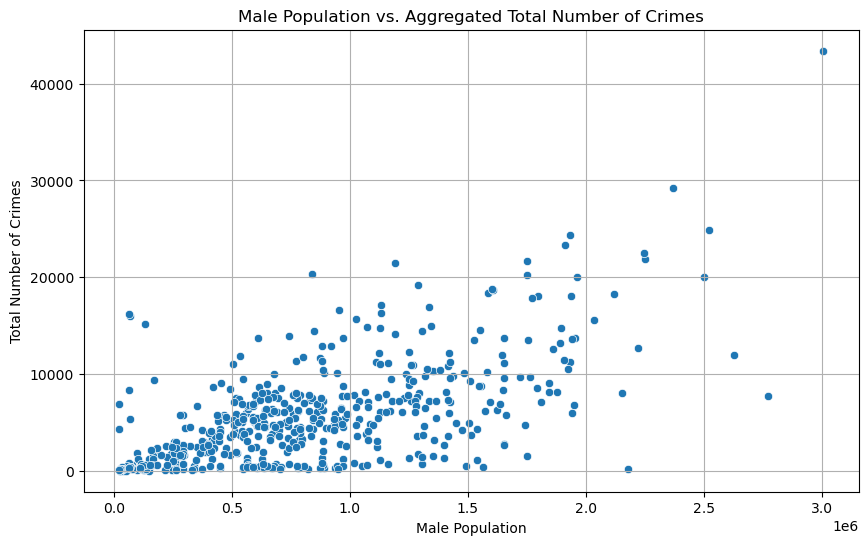

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_male_popln_vs_aggregated_crimes(state=None, district=None):
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    aggregated_crimes = filtered_data.groupby(['state', 'District', 'Male Population'])['total'].sum().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Male Population', y='total', data=aggregated_crimes)
    plt.title('Male Population vs. Aggregated Total Number of Crimes')
    plt.xlabel('Male Population')
    plt.ylabel('Total Number of Crimes')
    plt.grid(True)
    plt.show()

plot_male_popln_vs_aggregated_crimes()


<h3>Checking Total number of crimes vs Urban Population</h3>

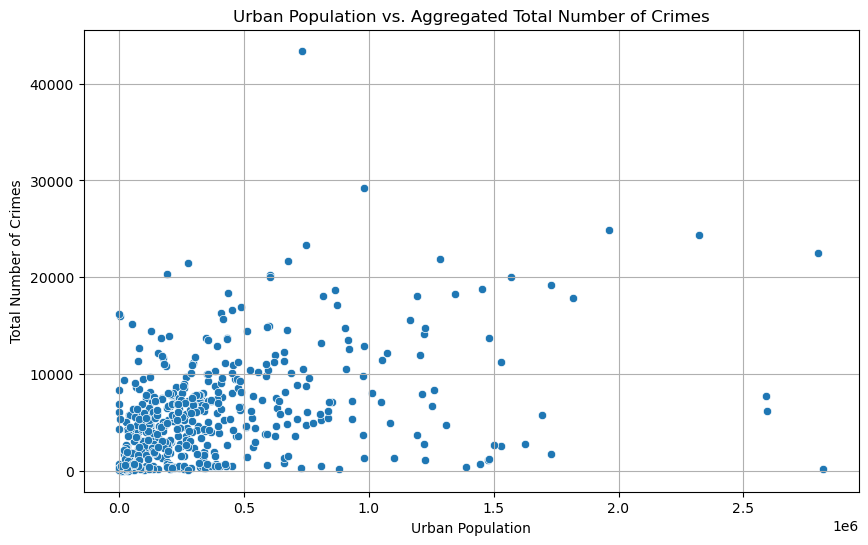

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_male_popln_vs_aggregated_crimes(state=None, district=None):
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    aggregated_crimes = filtered_data.groupby(['state', 'District', 'urban_population'])['total'].sum().reset_index()
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='urban_population', y='total', data=aggregated_crimes)
    plt.title('Urban Population vs. Aggregated Total Number of Crimes')
    plt.xlabel('Urban Population')
    plt.ylabel('Total Number of Crimes')
    plt.grid(True)
    plt.show()

plot_male_popln_vs_aggregated_crimes()

<h2>Outlier Detection using KNN Model</h2>

In [90]:
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler


numeric_df = final_df.select_dtypes(include=['number'])

numeric_df = numeric_df.fillna(numeric_df.mean())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


k = 50 
clf = LocalOutlierFactor(n_neighbors=k, contamination=0.01)  
outlier_scores = clf.fit_predict(scaled_data)

outliers = numeric_df[outlier_scores == -1]

print("Outliers:")
print(outliers)


Outliers:
        YEAR  MURDER  ATTEMPT TO MURDER  RAPE  CUSTODIAL RAPE  OTHER RAPE  \
591   2010.0    83.0                 67   148             3.0       145.0   
752   2005.0    68.0                108     6             0.0         6.0   
783   2006.0   158.0                178    25             0.0        25.0   
953   2012.0   198.0                611    34             0.0        34.0   
972   2001.0   434.0                581    27             0.0        27.0   
...      ...     ...                ...   ...             ...         ...   
6195  2010.0   185.0                620   526             0.0       526.0   
6196  2011.0   145.0                637   433             0.0       433.0   
6197  2012.0   174.0                395   257             0.0       257.0   
6203  2004.0    99.0                  0   108             0.0       108.0   
6204  2005.0   100.0                  0   148             0.0       148.0   

      KIDNAPPING & ABDUCTION  KIDNAPPING AND ABDUCTION OF WOMEN A

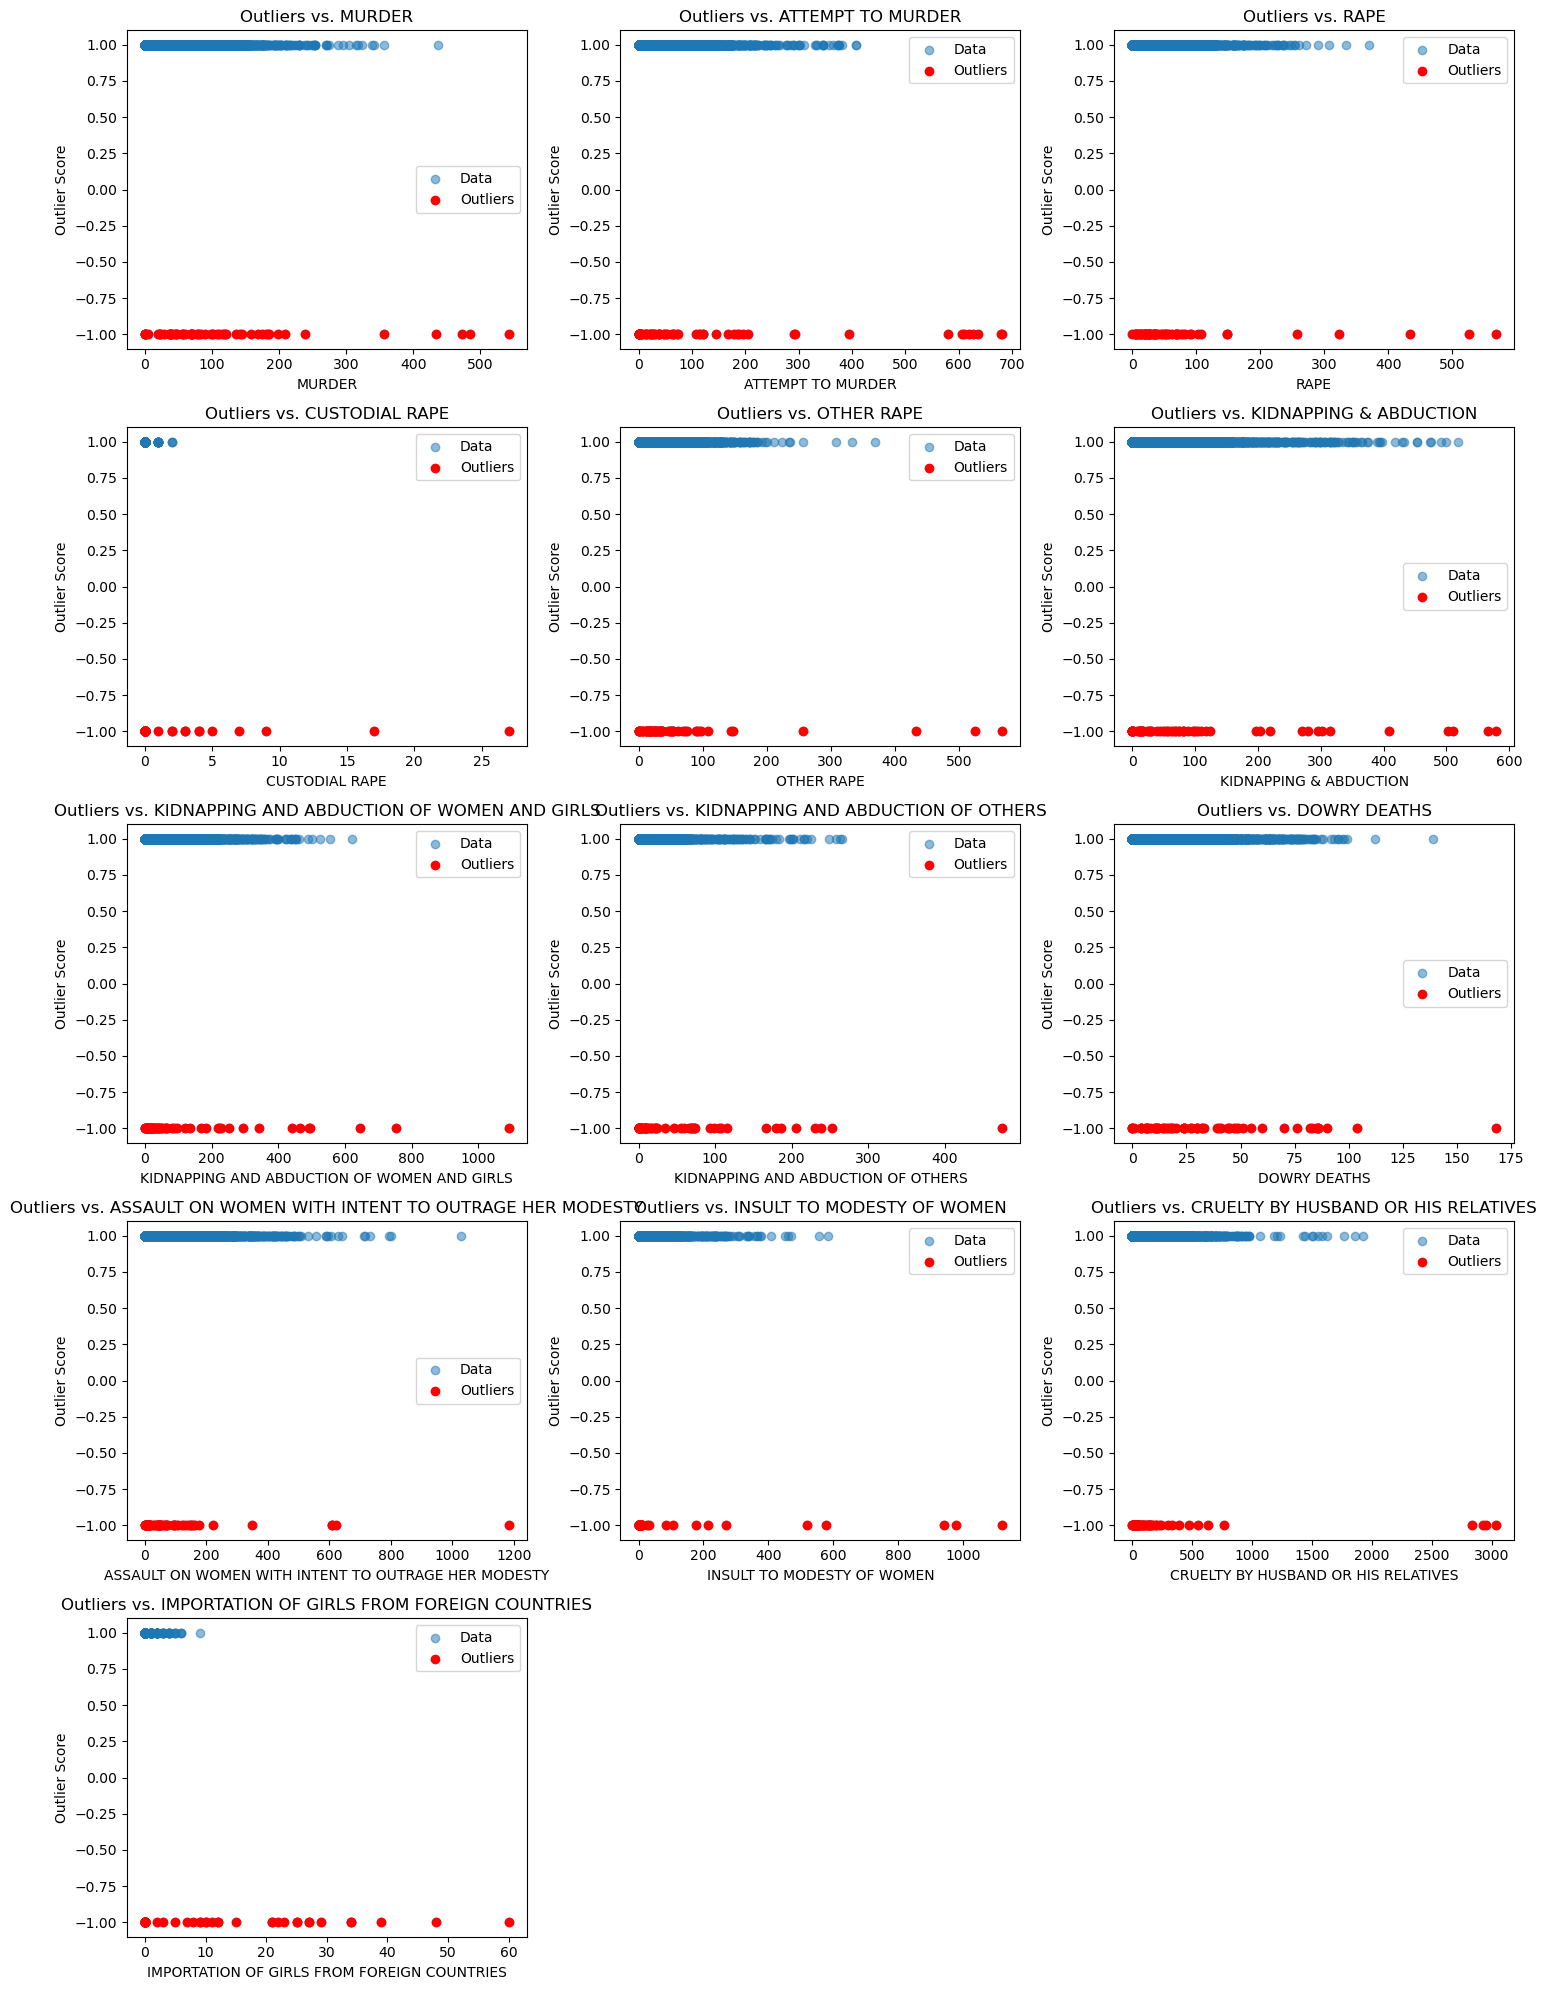

In [91]:
import matplotlib.pyplot as plt


selected_features = ['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                     'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                     'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                     'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                     'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                     'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES']

outlier_df = pd.DataFrame(outlier_scores, columns=['Outlier Score'], index=numeric_df.index)

numeric_df_with_outliers = pd.concat([numeric_df, outlier_df], axis=1)

fig, axs = plt.subplots(nrows=len(selected_features) // 3 + 1, ncols=3, figsize=(15, 20))

for i, feature in enumerate(selected_features):
    row = i // 3
    col = i % 3
    axs[row, col].scatter(numeric_df_with_outliers[feature], numeric_df_with_outliers['Outlier Score'], alpha=0.5, label='Data')
    axs[row, col].scatter(numeric_df_with_outliers[feature][outlier_scores == -1], outlier_df['Outlier Score'][outlier_scores == -1], color='red', label='Outliers')
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel('Outlier Score')
    axs[row, col].set_title(f'Outliers vs. {feature}')
    axs[row, col].legend()

    
fig.delaxes(axs[4, 1])
fig.delaxes(axs[4, 2])

plt.tight_layout()
plt.show()


<H2>FORECASTING CRIME TRENDS</H2>
<ol><li>First plot shows the original trend</li>
<li>Second plot shows the trend alongside 5 year forecast using linear regression</li>
<li>Third plot shows the trend alongside 5 year forecast using ARIMA model</li></ol>

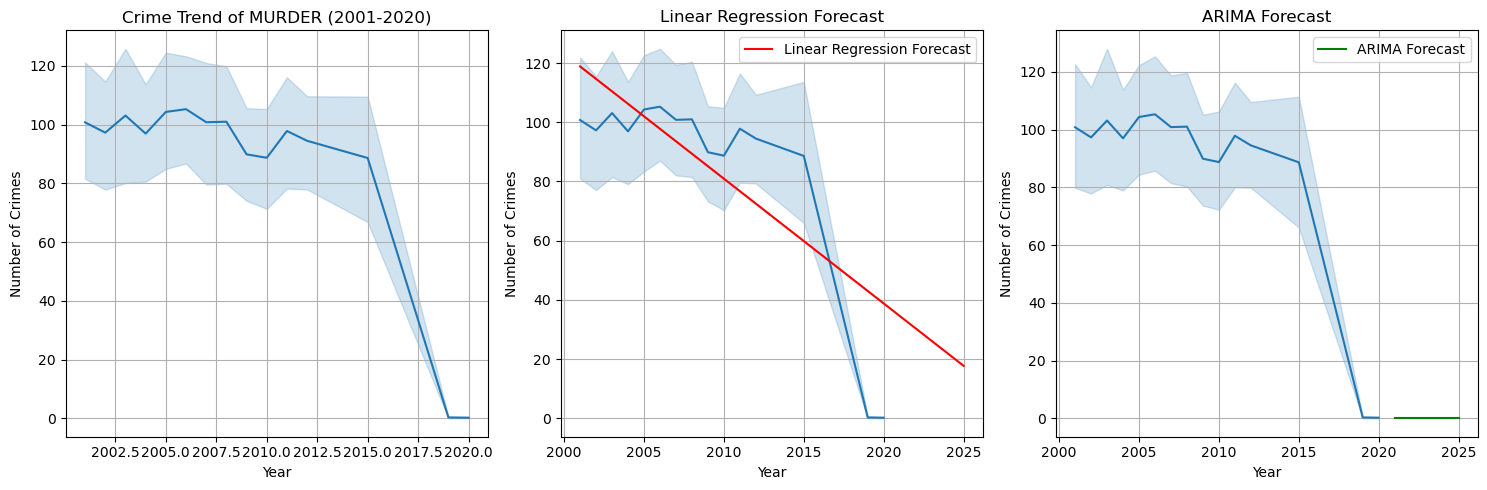

interactive(children=(Dropdown(description='State:', layout=Layout(width='300px'), options=('ANDHRA PRADESH', …

<function __main__.plot_crime_forecast(state, district, crime, year_range)>

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Layout
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import numpy as np

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:', layout=Layout(width='300px'))
district_dropdown = widgets.Dropdown(description='District:', layout=Layout(width='300px'))
crime_dropdown = widgets.Dropdown(options=all_crimes, description='Crime:', layout=Layout(width='300px'))
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

def plot_crime_forecast(state, district, crime, year_range):
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    filtered_data = filtered_data[(filtered_data['YEAR'] >= year_range[0]) & (filtered_data['YEAR'] <= year_range[1])]
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    sns.lineplot(x='YEAR', y=crime, data=filtered_data)
    plt.title(f'Crime Trend of {crime} ({year_range[0]}-{year_range[1]})')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    
    X = filtered_data[['YEAR']].values
    y = filtered_data[crime].values
    model_lr = LinearRegression()
    model_lr.fit(X, y)
    forecast_lr = model_lr.predict(X)
    
    future_years = np.arange(year_range[1] + 1, year_range[1] + 6)
    forecast_lr_future = model_lr.predict(future_years.reshape(-1, 1))
    
    plt.subplot(1, 3, 2)
    sns.lineplot(x='YEAR', y=crime, data=filtered_data)
    sns.lineplot(x=np.concatenate((filtered_data['YEAR'], future_years)), y=np.concatenate((forecast_lr, forecast_lr_future)), color='red', label='Linear Regression Forecast')
    plt.title('Linear Regression Forecast')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    
    model_arima = ARIMA(y, order=(5,1,0))
    model_arima_fit = model_arima.fit()
    forecast_arima = model_arima_fit.forecast(steps=5)
    
    plt.subplot(1, 3, 3)
    sns.lineplot(x='YEAR', y=crime, data=filtered_data)
    sns.lineplot(x=range(year_range[1]+1, year_range[1]+6), y=forecast_arima, color='green', label='ARIMA Forecast')
    plt.title('ARIMA Forecast')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_forecast, state=state_dropdown, district=district_dropdown, crime=crime_dropdown, year_range=year_range_slider)


<h1>Crime Distribution State-wise</h1>

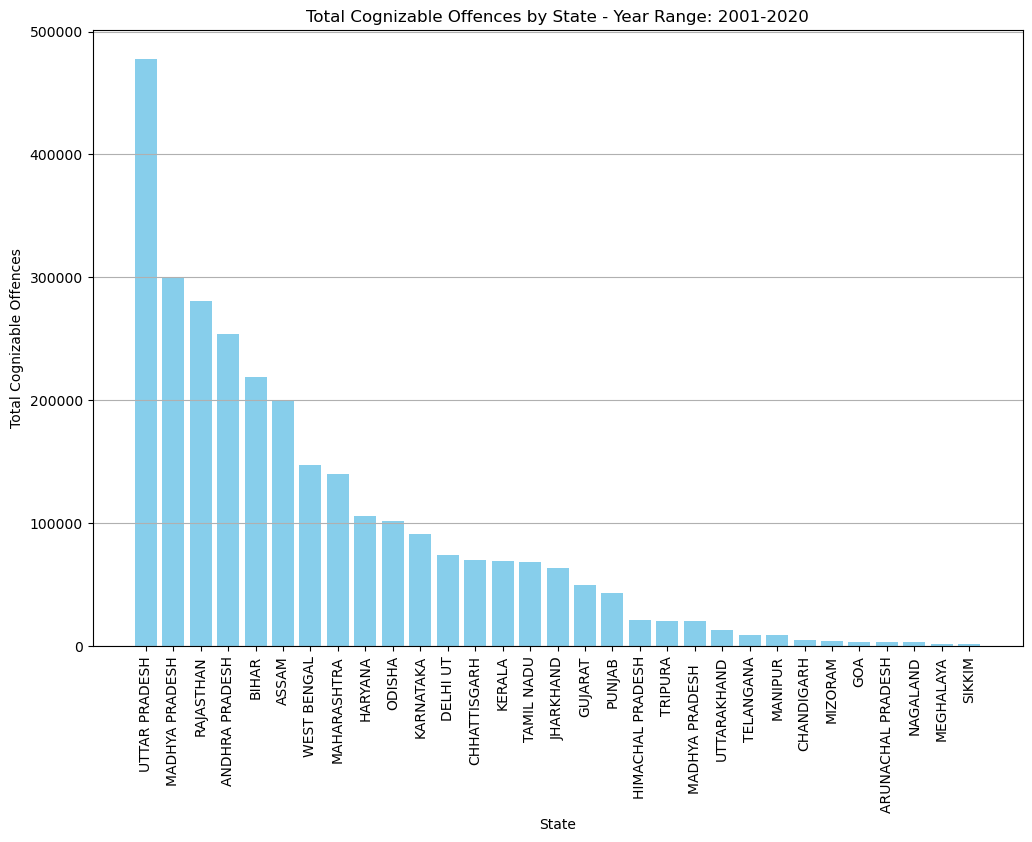

interactive(children=(IntRangeSlider(value=(2001, 2020), description='Year Range:', max=2020, min=2001), Outpu…

<function __main__.plot_total_crimes_by_state(year_range)>

In [122]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_total_crimes_by_state(year_range):
    filtered_df = final_df[final_df['YEAR'].between(year_range[0], year_range[1])]
    
    total_crimes_by_state = filtered_df.groupby('state')['Total Cognizable Offences'].sum().reset_index()

    total_crimes_by_state = total_crimes_by_state.sort_values(by='Total Cognizable Offences', ascending=False)

    plt.figure(figsize=(12, 8))
    plt.bar(total_crimes_by_state['state'], total_crimes_by_state['Total Cognizable Offences'], color='skyblue')
    plt.xticks(rotation=90)
    plt.xlabel('State')
    plt.ylabel('Total Cognizable Offences')
    plt.title(f'Total Cognizable Offences by State - Year Range: {year_range[0]}-{year_range[1]}')
    plt.grid(axis='y')
    plt.show()

year_range_slider = widgets.IntRangeSlider(min=final_df['YEAR'].min(), 
                                            max=final_df['YEAR'].max(), 
                                            step=1, 
                                            value=[final_df['YEAR'].min(), final_df['YEAR'].max()], 
                                            description='Year Range:')

interact(plot_total_crimes_by_state, year_range=year_range_slider)
